# Task 3: Handwritten Character Recognition — CodeAlpha ML Internship

**Objective:** Recognize handwritten digits (0-9) from images using deep learning.

**Dataset:** MNIST — 70,000 grayscale images (28x28 pixels) of handwritten digits, the standard benchmark for image classification.

**Approach:** Build and train a Convolutional Neural Network (CNN) to classify digits, then evaluate performance and visualize predictions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## 1. Load and Explore the Dataset

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training set: (60000, 28, 28), (60000,)
Test set: (10000, 28, 28), (10000,)


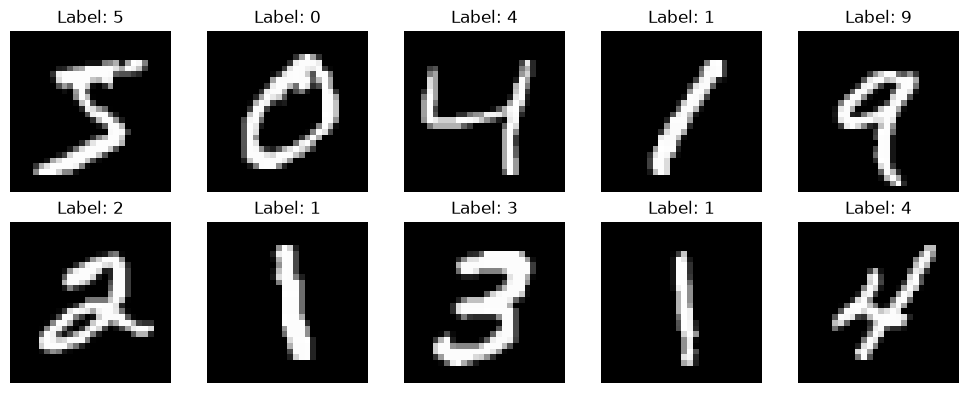

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_digits.png', bbox_inches='tight')
plt.show()

## 2. Preprocessing
Pixel values are normalized to 0-1, images are reshaped to include a channel dimension for the CNN, and labels are one-hot encoded for multi-class classification.

In [3]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(f"X_train shape: {X_train.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")

X_train shape: (60000, 28, 28, 1)
y_train_cat shape: (60000, 10)


## 3. Build the CNN
The architecture uses two convolutional blocks (Conv2D + MaxPooling) to progressively extract spatial features, followed by dense layers for final classification into 10 digit classes.

In [4]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\freya\Desktop\CodeAlpha_MachineLearning\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Model
The model is trained for 10 epochs with a validation split to monitor performance on unseen data during training.

In [5]:
history = model.fit(X_train, y_train_cat, epochs=10, batch_size=128,
                     validation_split=0.1, verbose=1)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9138 - loss: 0.2820 - val_accuracy: 0.9828 - val_loss: 0.0640
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9765 - loss: 0.0766 - val_accuracy: 0.9858 - val_loss: 0.0479
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9834 - loss: 0.0553 - val_accuracy: 0.9895 - val_loss: 0.0335
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9867 - loss: 0.0439 - val_accuracy: 0.9910 - val_loss: 0.0333
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9883 - loss: 0.0362 - val_accuracy: 0.9902 - val_loss: 0.0363
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9909 - loss: 0.0297 - val_accuracy: 0.9905 - val_loss: 0.0341
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9920 - loss: 0.0266 - val_accuracy: 0.9920 - val_loss: 0.0318
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9926 - loss: 0.0233 - val_acc

## 5. Training Curves
Visualizing accuracy and loss over epochs confirms stable learning without overfitting.

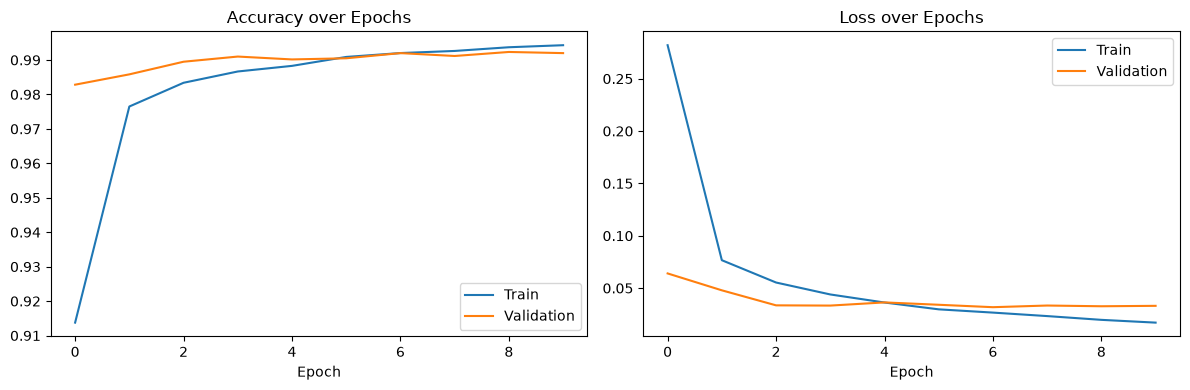

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/training_curves.png', bbox_inches='tight')
plt.show()

## 6. Evaluate on Test Set

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9919
Test Loss: 0.0261
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## 7. Confusion Matrix & Sample Predictions

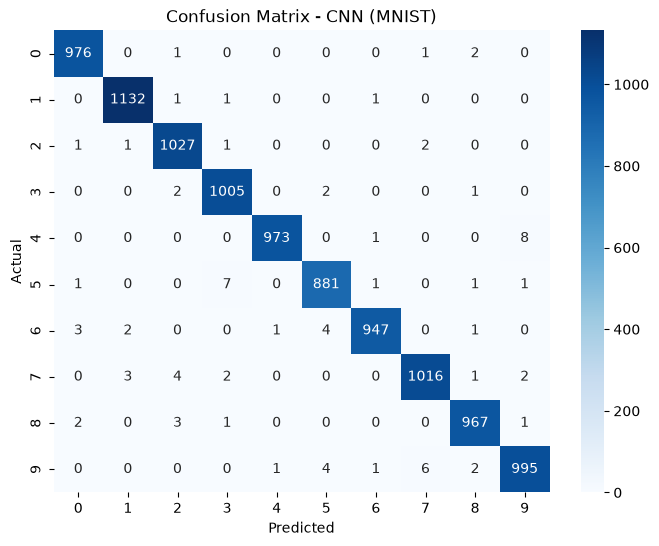

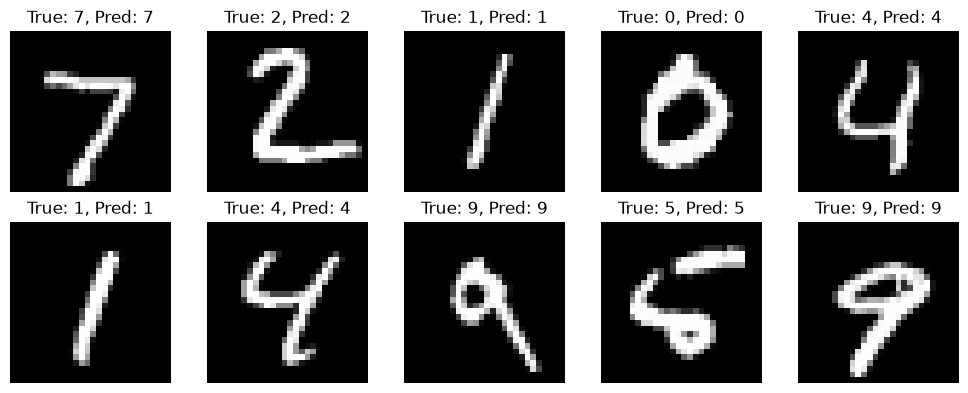

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN (MNIST)')
plt.savefig('results/confusion_matrix.png', bbox_inches='tight')
plt.show()

# Show a few actual predictions on real test images
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    ax.set_title(f"True: {y_test[i]}, Pred: {y_pred[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('results/sample_predictions.png', bbox_inches='tight')
plt.show()

In [11]:
import os
os.makedirs('models', exist_ok=True)
model.save('models/mnist_cnn_model.keras')
print("Model saved.")

Model saved.


## 8. Summary

A CNN with two convolutional blocks was trained on the MNIST dataset (60,000 training images, 10,000 test images) to classify handwritten digits (0-9).

**Test Accuracy: 99.19%** | **Test Loss: 0.0261**

All 10 digit classes achieved 0.99 F1-score with no significant weak spots. The confusion matrix shows the model's rare errors occur between visually similar digit pairs (e.g. 9 confused with 4 or 7), consistent with genuine handwriting ambiguity rather than random error. Training and validation accuracy tracked closely throughout training, indicating no overfitting.